In [8]:
import numpy as np
#import tensorflow as tf
from keras import layers
from keras.layers import Input, Dense, Activation, ZeroPadding2D, BatchNormalization, Flatten, Conv2D
from keras.layers import AveragePooling2D, MaxPooling2D, Dropout, GlobalMaxPooling2D, GlobalAveragePooling2D
from keras.models import Model
from keras.preprocessing import image
from keras.utils import layer_utils
from keras.utils.data_utils import get_file
from keras.applications.imagenet_utils import preprocess_input
import pydot
from IPython.display import SVG
from keras.utils.vis_utils import model_to_dot
from keras.utils import plot_model, to_categorical
from kt_utils import *

import keras.backend as K
K.set_image_data_format('channels_last')
import matplotlib.pyplot as plt
from matplotlib.pyplot import imshow

# get_ipython().run_line_magic('matplotlib', 'inline')

In [9]:
X_train_orig, Y_train_orig, X_test_orig, Y_test_orig, classes = load_dataset()

# Normalize image vectors
X_train = X_train_orig/255.
X_test = X_test_orig/255.

# Reshape
Y_train = to_categorical(Y_train_orig.T) # to_categorical() , keras function of one-hot encode
Y_test = to_categorical(Y_test_orig.T)

print ("number of training examples = " + str(X_train.shape[0]))
print ("number of test examples = " + str(X_test.shape[0]))
print ("X_train shape: " + str(X_train.shape))
print ("Y_train shape: " + str(Y_train.shape))
print ("X_test shape: " + str(X_test.shape))
print ("Y_test shape: " + str(Y_test.shape))

number of training examples = 1080
number of test examples = 120
X_train shape: (1080, 64, 64, 3)
Y_train shape: (1080, 6)
X_test shape: (120, 64, 64, 3)
Y_test shape: (120, 6)


In [58]:
def SIGNModel(input_shape):
    """
    Implementation of the SIGN.
    
    Arguments:
    input_shape -- shape of the images of the dataset

    Returns:
    model -- a Model() instance in Keras
    """
    ### START CODE HERE ###
    # Feel free to use the suggested outline in the text above to get started, and run through the whole
    # exercise (including the later portions of this notebook) once. The come back also try out other
    # network architectures as well. 
    X_input = Input(shape=input_shape)
    X = ZeroPadding2D(padding=(1, 1))(X_input)
    X = Conv2D(32, kernel_size=(3,3), strides=(1,1))(X)
    X = BatchNormalization(axis=3)(X)
    X = Activation('relu')(X)
    X = MaxPooling2D(pool_size=(2,2), strides=(2,2), padding='valid')(X)
    
    X = ZeroPadding2D(padding=(1, 1))(X)
    X = Conv2D(16, kernel_size=(3,3), strides=(1,1))(X)
    X = BatchNormalization(axis=3)(X)
    X = Activation('relu')(X)
    X = MaxPooling2D(pool_size=(2,2), strides=(2,2), padding='valid')(X)
    
#     X = ZeroPadding2D(padding=(1, 1))(X)
#     X = Conv2D(8, kernel_size=(2,2), strides=(1,1))(X)
#     X = BatchNormalization(axis=3)(X)
#     X = Activation('relu')(X)
#     X = MaxPooling2D(pool_size=(2,2), strides=(2,2), padding='valid')(X)
    
    # FC
    X  = Flatten()(X)
    Y1 = Dense(6,activation=None)(X)
    Y  = Activation("softmax")(Y1)
    
    model = Model(inputs = X_input, outputs = Y, name='SIGNModel')  
    ### END CODE HERE ###
    
    return model

In [59]:
### START CODE HERE ### (1 line)
    
SIGNModel =  SIGNModel((64, 64, 3))

### END CODE HERE ###

(?, ?)
(?, 6)
(?, 6)


In [60]:
### START CODE HERE ### (1 line)
#import keras
# optimizer: sgd, adam, RMSprop, Adagrad...
# loss: categorical_crossentropy for multiple classification

SIGNModel.compile(optimizer = "sgd", loss = "categorical_crossentropy", metrics = ["accuracy"]) 



### END CODE HERE ###

In [61]:
### START CODE HERE ### (1 line)
# epochs & batch_size can adjust


SIGNModel.fit(X_train,Y_train, epochs = 10, batch_size=16 ) 

### END CODE HERE ###

Epoch 1/10
1080/1080 [==============================] - 40s 37ms/step - loss: 2.8424 - acc: 0.4139
Epoch 2/10
1080/1080 [==============================] - 39s 36ms/step - loss: 0.7213 - acc: 0.7491
Epoch 3/10
1080/1080 [==============================] - 39s 36ms/step - loss: 0.4330 - acc: 0.8454
Epoch 4/10
1080/1080 [==============================] - 39s 36ms/step - loss: 0.3035 - acc: 0.9120
Epoch 5/10
1080/1080 [==============================] - 39s 36ms/step - loss: 0.2114 - acc: 0.9380
Epoch 6/10
1080/1080 [==============================] - 38s 36ms/step - loss: 0.1430 - acc: 0.9704
Epoch 7/10
1080/1080 [==============================] - 39s 36ms/step - loss: 0.1080 - acc: 0.9815
Epoch 8/10
1080/1080 [==============================] - 39s 36ms/step - loss: 0.0888 - acc: 0.9852
Epoch 9/10
1080/1080 [==============================] - 38s 35ms/step - loss: 0.0626 - acc: 0.9963
Epoch 10/10
1080/1080 [==============================] - 39s 36ms/step - loss: 0.0542 - acc: 0.9954


In [62]:
SIGNModel.summary()

_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_14 (InputLayer)        (None, 64, 64, 3)         0         
_________________________________________________________________
zero_padding2d_30 (ZeroPaddi (None, 66, 66, 3)         0         
_________________________________________________________________
conv2d_30 (Conv2D)           (None, 64, 64, 32)        896       
_________________________________________________________________
batch_normalization_30 (Batc (None, 64, 64, 32)        128       
_________________________________________________________________
activation_43 (Activation)   (None, 64, 64, 32)        0         
_________________________________________________________________
max_pooling2d_30 (MaxPooling (None, 32, 32, 32)        0         
_________________________________________________________________
zero_padding2d_31 (ZeroPaddi (None, 34, 34, 32)        0         
__________

In [66]:
### START CODE HERE ### (1 line)

preds =  SIGNModel.evaluate(X_test, Y_test, batch_size= 32)


### END CODE HERE ###
print("SIGNModel")
print ("Loss = " + str(preds[0]))
print ("Test Accuracy = " + str(preds[1]))


120/120 [==============================] - 1s 9ms/step
SIGNModel
Loss = 0.18234131236871085
Test Accuracy = 0.949999996026357


The figure is 3


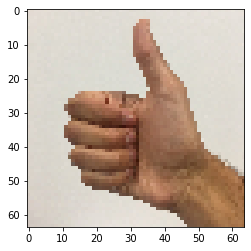

In [67]:
### START CODE HERE ###
img_path = 'images/test_1.jpg'
### END CODE HERE ###
img = image.load_img(img_path, target_size=(64, 64))
imshow(img)

x1 = image.img_to_array(img)
x2 = np.expand_dims(x1, axis=0)
x3 = preprocess_input(x2)
x_out = np.argmax(SIGNModel.predict(x3))
print('The figure is',x_out)


In [64]:
    X_input = Input((64, 64, 3))
    X = ZeroPadding2D(padding=(1, 1))(X_input)
    X = Conv2D(32, kernel_size=(3,3), strides=(1,1))(X)
    X = BatchNormalization(axis=3)(X)
    X = Activation('relu')(X)
    X = MaxPooling2D(pool_size=(2,2), strides=(2,2), padding='valid')(X)
    
    X = ZeroPadding2D(padding=(1, 1))(X)
    X = Conv2D(32, kernel_size=(3,3), strides=(1,1))(X)
    X = BatchNormalization(axis=3)(X)
    X = Activation('relu')(X)
    X = MaxPooling2D(pool_size=(2,2), strides=(2,2), padding='valid')(X)
    
#     X = ZeroPadding2D(padding=(1, 1))(X)
#     X = Conv2D(8, kernel_size=(2,2), strides=(1,1))(X)
#     X = BatchNormalization(axis=3)(X)
#     X = Activation('relu')(X)
#     X = MaxPooling2D(pool_size=(2,2), strides=(2,2), padding='valid')(X)
    
    # FC
    X  = Flatten()(X)
    Y1 = Dense(6,activation=None)(X)
    Y  = Activation("softmax")(Y1)
    
    model = Model(inputs = X_input, outputs = Y, name='SIGNModel') 
    model.compile(optimizer = "sgd", loss = "categorical_crossentropy", metrics = ["accuracy"])
    model.fit(X_train,Y_train, epochs = 10, batch_size=16 ) 


Epoch 1/10
1080/1080 [==============================] - 65s 60ms/step - loss: 8.8812 - acc: 0.2981
Epoch 2/10
1080/1080 [==============================] - 63s 58ms/step - loss: 3.8333 - acc: 0.5963
Epoch 3/10
1080/1080 [==============================] - 63s 59ms/step - loss: 2.8709 - acc: 0.7593
Epoch 4/10
1080/1080 [==============================] - 64s 59ms/step - loss: 2.7941 - acc: 0.8037
Epoch 5/10
1080/1080 [==============================] - 66s 61ms/step - loss: 2.7170 - acc: 0.7889
Epoch 6/10
1080/1080 [==============================] - 61s 57ms/step - loss: 0.6232 - acc: 0.8481
Epoch 7/10
1080/1080 [==============================] - 61s 57ms/step - loss: 0.1730 - acc: 0.9454
Epoch 8/10
1080/1080 [==============================] - 58s 54ms/step - loss: 0.1370 - acc: 0.9574
Epoch 9/10
1080/1080 [==============================] - 52s 48ms/step - loss: 0.0622 - acc: 0.9796
Epoch 10/10
1080/1080 [==============================] - 42s 39ms/step - loss: 0.0363 - acc: 0.9935


In [65]:
model.summary()

_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_16 (InputLayer)        (None, 64, 64, 3)         0         
_________________________________________________________________
zero_padding2d_34 (ZeroPaddi (None, 66, 66, 3)         0         
_________________________________________________________________
conv2d_34 (Conv2D)           (None, 64, 64, 32)        896       
_________________________________________________________________
batch_normalization_34 (Batc (None, 64, 64, 32)        128       
_________________________________________________________________
activation_49 (Activation)   (None, 64, 64, 32)        0         
_________________________________________________________________
max_pooling2d_34 (MaxPooling (None, 32, 32, 32)        0         
_________________________________________________________________
zero_padding2d_35 (ZeroPaddi (None, 34, 34, 32)        0         
__________

120/120 [==============================] - 1s 10ms/step
model
Loss = 0.49883023301760354
Test Accuracy = 0.8333333293596904
The figure is 2


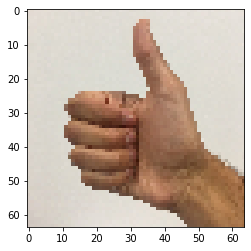

In [68]:
predtions =  model.evaluate(X_test, Y_test, batch_size= 32)


### END CODE HERE ###
print("model")
print ("Loss = " + str(predtions[0]))
print ("Test Accuracy = " + str(predtions[1]))
### START CODE HERE ###
img_path = 'images/test_1.jpg'
### END CODE HERE ###
img = image.load_img(img_path, target_size=(64, 64))
imshow(img)

x1 = image.img_to_array(img)
x2 = np.expand_dims(x1, axis=0)
x3 = preprocess_input(x2)
x_out = np.argmax(model.predict(x3))
print('The figure is',x_out)

Epoch 1/10
1080/1080 [==============================] - 42s 39ms/step - loss: 4.6281 - acc: 0.2259
Epoch 2/10
1080/1080 [==============================] - 43s 40ms/step - loss: 1.2585 - acc: 0.5352
Epoch 3/10
1080/1080 [==============================] - 43s 40ms/step - loss: 0.8665 - acc: 0.6981
Epoch 4/10
1080/1080 [==============================] - 44s 40ms/step - loss: 0.6839 - acc: 0.7806
Epoch 5/10
1080/1080 [==============================] - 50s 46ms/step - loss: 0.5945 - acc: 0.8019
Epoch 6/10
1080/1080 [==============================] - 45s 41ms/step - loss: 0.4319 - acc: 0.8806
Epoch 7/10
1080/1080 [==============================] - 43s 40ms/step - loss: 0.3829 - acc: 0.9009
Epoch 8/10
1080/1080 [==============================] - 46s 43ms/step - loss: 0.3252 - acc: 0.9130
Epoch 9/10
1080/1080 [==============================] - 44s 41ms/step - loss: 0.2753 - acc: 0.9435
Epoch 10/10
120/120 [==============================] - 1s 12ms/step
model
Loss = 0.4841639757156372
Test Accu

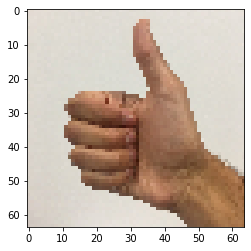

In [80]:
    X_input = Input((64, 64, 3))
    X = ZeroPadding2D(padding=(1, 1))(X_input)
    X = Conv2D(32, kernel_size=(3,3), strides=(1,1))(X)
    X = BatchNormalization(axis=3)(X)
    X = Activation('relu')(X)
    X = MaxPooling2D(pool_size=(2,2), strides=(2,2), padding='valid')(X)
    
    X = ZeroPadding2D(padding=(1, 1))(X)
    X = Conv2D(16, kernel_size=(3,3), strides=(1,1))(X)
    X = BatchNormalization(axis=3)(X)
    X = Activation('relu')(X)
    X = MaxPooling2D(pool_size=(2,2), strides=(2,2), padding='valid')(X)
    
#     X = ZeroPadding2D(padding=(1, 1))(X)
#     X = Conv2D(8, kernel_size=(2,2), strides=(1,1))(X)
#     X = BatchNormalization(axis=3)(X)
#     X = Activation('relu')(X)
#     X = MaxPooling2D(pool_size=(2,2), strides=(2,2), padding='valid')(X)
    
    # FC
    X  = Flatten()(X)
    Y1 = Dense(6,activation=None)(X)
    Y  = Activation("softmax")(Y1)
    
    model = Model(inputs = X_input, outputs = Y, name='SIGNModel') 
    model.compile(optimizer = "sgd", loss = "categorical_crossentropy", metrics = ["accuracy"])
    model.fit(X_train,Y_train, epochs = 10, batch_size=64 ) 
    
    predtions =  model.evaluate(X_test, Y_test, batch_size= 32)


    ### END CODE HERE ###
    print("model")
    print ("Loss = " + str(predtions[0]))
    print ("Test Accuracy = " + str(predtions[1]))
    ### START CODE HERE ###
    img_path = 'images/test_1.jpg'
    ### END CODE HERE ###
    img = image.load_img(img_path, target_size=(64, 64))
    imshow(img)

    x1 = image.img_to_array(img)
    x2 = np.expand_dims(x1, axis=0)
    x3 = preprocess_input(x2)
    x_out = np.argmax(model.predict(x3))
    print('The figure is',x_out)


In [71]:
    X_input = Input((64, 64, 3))
    X = ZeroPadding2D(padding=(1, 1))(X_input)
    X = Conv2D(32, kernel_size=(3,3), strides=(1,1))(X)
    X = BatchNormalization(axis=3)(X)
    X = Activation('relu')(X)
    X = MaxPooling2D(pool_size=(2,2), strides=(2,2), padding='valid')(X)
    
    X = ZeroPadding2D(padding=(1, 1))(X)
    X = Conv2D(16, kernel_size=(3,3), strides=(1,1))(X)
    X = BatchNormalization(axis=3)(X)
    X = Activation('relu')(X)
    X = MaxPooling2D(pool_size=(2,2), strides=(2,2), padding='valid')(X)
    
    X = ZeroPadding2D(padding=(1, 1))(X)
    X = Conv2D(8, kernel_size=(2,2), strides=(1,1))(X)
    X = BatchNormalization(axis=3)(X)
    X = Activation('relu')(X)
    X = MaxPooling2D(pool_size=(2,2), strides=(2,2), padding='valid')(X)
    
    # FC
    X  = Flatten()(X)
    Y1 = Dense(6,activation=None)(X)
    Y  = Activation("softmax")(Y1)
    
    model = Model(inputs = X_input, outputs = Y, name='SIGNModel') 
    model.compile(optimizer = "sgd", loss = "categorical_crossentropy", metrics = ["accuracy"])
    model.fit(X_train,Y_train, epochs = 10, batch_size=16 ) 


Epoch 1/10
1080/1080 [==============================] - 503s 466ms/step - loss: 1.7599 - acc: 0.2944
Epoch 2/10
1080/1080 [==============================] - 564s 522ms/step - loss: 1.1296 - acc: 0.5833
Epoch 3/10
1080/1080 [==============================] - 543s 503ms/step - loss: 0.7457 - acc: 0.7528
Epoch 4/10
1080/1080 [==============================] - 525s 486ms/step - loss: 0.5359 - acc: 0.8333
Epoch 5/10
1080/1080 [==============================] - 525s 487ms/step - loss: 0.4295 - acc: 0.8620
Epoch 6/10
1080/1080 [==============================] - 533s 493ms/step - loss: 0.3244 - acc: 0.9065
Epoch 7/10
1080/1080 [==============================] - 512s 474ms/step - loss: 0.2792 - acc: 0.9185
Epoch 8/10
1080/1080 [==============================] - 580s 537ms/step - loss: 0.2199 - acc: 0.9509
Epoch 9/10
1080/1080 [==============================] - 480s 444ms/step - loss: 0.1825 - acc: 0.9556
Epoch 10/10
1080/1080 [==============================] - 530s 490ms/step - loss: 0.1507 - a

120/120 [==============================] - 1s 11ms/step
model
Loss = 0.5322820583979289
Test Accuracy = 0.8083333333333333
The figure is 2


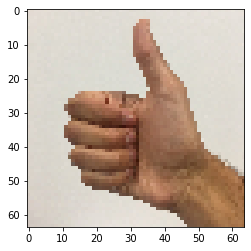

In [72]:
predtions =  model.evaluate(X_test, Y_test, batch_size= 32)


### END CODE HERE ###
print("model")
print ("Loss = " + str(predtions[0]))
print ("Test Accuracy = " + str(predtions[1]))
### START CODE HERE ###
img_path = 'images/test_1.jpg'
### END CODE HERE ###
img = image.load_img(img_path, target_size=(64, 64))
imshow(img)

x1 = image.img_to_array(img)
x2 = np.expand_dims(x1, axis=0)
x3 = preprocess_input(x2)
x_out = np.argmax(model.predict(x3))
print('The figure is',x_out)

In [79]:
keras.callbacks.History()